In [ ]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from wordcloud import WordCloud
import string
import IPython.display as display

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ruta= "/content/drive/MyDrive/Proyecto de profundización 1/PROYECTO GRADO 2025/Resultados modelos/canciones_clasificacion_emocion_IA.xlsx"
df = pd.read_excel(ruta, sheet_name = "Sheet1")
df.head()

,TITULO,AÑO,COMPOSITOR,UBICACIÓN,DEPARTAMENTO,URL,GENERO,AUDIO_NAME,LETRA,AUDIO_DESCARGADO,POLARIDAD,EMOCION
0,A CHUPAR,1990,ISAAC VILLANUEVA MENDOZA,BARRANQUILLA,ATLANTICO,https://www.youtube.com/watch?v=iS2pl7Q-L6Y,SALSA,A CHUPAR_1990_ISAAC VILLANUEVA MENDOZA,rico caramelo tú tú así como yo te quiero te q...,True,Positivo,Alegría
1,A MI MANERA TE QUIERO,1990,IVAN ANTONIO OVALLE POVEDA,BARRANQUILLA,ATLANTICO,https://www.youtube.com/watch?v=B2jyjZgzPG8,VALLENATO,A MI MANERA TE QUIERO_1990_IVAN ANTONIO OVALLE...,es una idea papá yo sé que tú eres muy feliz t...,True,Positivo,Tristeza
2,A MI PADRE,1990,NORBERTO RIVEROS SANTOS,VILLAVICENCIO,META,https://www.youtube.com/watch?v=gAVBGPKNJ1I,Ranchera,A MI PADRE_1990_NORBERTO RIVEROS SANTOS,stitch con amor van es todo un erizo a mi padr...,True,Positivo,Alegría
3,A UN GRAN AMIGO,1990,IVAN ANTONIO OVALLE POVEDA,BARRANQUILLA,ATLANTICO,https://www.youtube.com/watch?v=Js6n4EEnU4w,VALLENATO,A UN GRAN AMIGO_1990_IVAN ANTONIO OVALLE POVEDA,esta canción la dedico a un gran amigo con muc...,True,Positivo,Ira
4,A UN PÁJARO EN LA NIEBLA,1990,CARLOS EDUARDO LÓPEZ DÁVILA,PASTO,NARIÑO,https://www.youtube.com/watch?v=Wzosax5uvLg,BOLERO,A UN PÁJARO EN LA NIEBLA_1990_CARLOS EDUARDO L...,quizás no pueda regalarte una palabra nueva y ...,True,Negativo,Miedo


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3712 entries, 0 to 3711
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   TITULO            3712 non-null   object
 1   AÑO               3712 non-null   int64 
 2   COMPOSITOR        3712 non-null   object
 3   UBICACIÓN         3712 non-null   object
 4   DEPARTAMENTO      3712 non-null   object
 5   URL               3712 non-null   object
 6   GENERO            3712 non-null   object
 7   AUDIO_NAME        3712 non-null   object
 8   LETRA             3712 non-null   object
 9   AUDIO_DESCARGADO  3712 non-null   bool  
 10  POLARIDAD         3430 non-null   object
 11  EMOCION           3712 non-null   object
dtypes: bool(1), int64(1), object(10)
memory usage: 322.8+ KB


In [ ]:
def informe(df: pd.DataFrame) -> pd.DataFrame:
    desc = []

    for i, col in enumerate(df.columns):
        serie = df[col]

        non_null = serie.notnull().sum()
        nulls = serie.isnull().sum()
        distinct = serie.nunique(dropna=True)

        if not serie.dropna().empty: top_val = serie.mode().iloc[0]
        else: top_val = None
        fq = (serie == top_val).sum()

        desc.append({"Columna": col, "Tipo": str(serie.dtype), "Valores": non_null, "Nulos": nulls, "Distintos": distinct,
                     "mas frecuente": top_val, "frecuencia":fq})

    return pd.DataFrame(desc)

In [ ]:
informe(df)

,Columna,Tipo,Valores,Nulos,Distintos,mas frecuente,frecuencia
0,TITULO,object,3712,0,3543,DIME,5
1,AÑO,int64,3712,0,34,1990,141
2,COMPOSITOR,object,3712,0,309,DARIO DE JESUS GOMEZ ZAPATA,132
3,UBICACIÓN,object,3712,0,70,BOGOTA D.C.,1543
4,DEPARTAMENTO,object,3712,0,25,BOGOTA D.C.,1543
5,URL,object,3712,0,3628,https://www.youtube.com/watch?v=37UlOp_LzIA,3
6,GENERO,object,3712,0,63,VALLENATO,499
7,AUDIO_NAME,object,3712,0,3684,LIBERTAD_1999_POLIKARPA Y SUS VICIOSAS,3
8,LETRA,object,3712,0,3653,desorden social presenta nada que callar Bienv...,12
9,AUDIO_DESCARGADO,bool,3712,0,2,True,3579


In [ ]:
# Filtrar quitando ese compositor
df = df[df["COMPOSITOR"].str.upper() != "JUAN MANUEL MORENO AVENDAÑO"]

In [ ]:
# Crear la columna llave
df.insert(0, "LLAVE", df["TITULO"].astype(str) + "_" + df["AÑO"].astype(str) + "_" + df["COMPOSITOR"].astype(str))
df.head()

,LLAVE,TITULO,AÑO,COMPOSITOR,UBICACIÓN,DEPARTAMENTO,URL,GENERO,AUDIO_NAME,LETRA,AUDIO_DESCARGADO,POLARIDAD,EMOCION
0,A CHUPAR_1990_ISAAC VILLANUEVA MENDOZA,A CHUPAR,1990,ISAAC VILLANUEVA MENDOZA,BARRANQUILLA,ATLANTICO,https://www.youtube.com/watch?v=iS2pl7Q-L6Y,SALSA,A CHUPAR_1990_ISAAC VILLANUEVA MENDOZA,rico caramelo tú tú así como yo te quiero te q...,True,Positivo,Alegría
1,A MI MANERA TE QUIERO_1990_IVAN ANTONIO OVALLE...,A MI MANERA TE QUIERO,1990,IVAN ANTONIO OVALLE POVEDA,BARRANQUILLA,ATLANTICO,https://www.youtube.com/watch?v=B2jyjZgzPG8,VALLENATO,A MI MANERA TE QUIERO_1990_IVAN ANTONIO OVALLE...,es una idea papá yo sé que tú eres muy feliz t...,True,Positivo,Tristeza
2,A MI PADRE_1990_NORBERTO RIVEROS SANTOS,A MI PADRE,1990,NORBERTO RIVEROS SANTOS,VILLAVICENCIO,META,https://www.youtube.com/watch?v=gAVBGPKNJ1I,Ranchera,A MI PADRE_1990_NORBERTO RIVEROS SANTOS,stitch con amor van es todo un erizo a mi padr...,True,Positivo,Alegría
3,A UN GRAN AMIGO_1990_IVAN ANTONIO OVALLE POVEDA,A UN GRAN AMIGO,1990,IVAN ANTONIO OVALLE POVEDA,BARRANQUILLA,ATLANTICO,https://www.youtube.com/watch?v=Js6n4EEnU4w,VALLENATO,A UN GRAN AMIGO_1990_IVAN ANTONIO OVALLE POVEDA,esta canción la dedico a un gran amigo con muc...,True,Positivo,Ira
4,A UN PÁJARO EN LA NIEBLA_1990_CARLOS EDUARDO L...,A UN PÁJARO EN LA NIEBLA,1990,CARLOS EDUARDO LÓPEZ DÁVILA,PASTO,NARIÑO,https://www.youtube.com/watch?v=Wzosax5uvLg,BOLERO,A UN PÁJARO EN LA NIEBLA_1990_CARLOS EDUARDO L...,quizás no pueda regalarte una palabra nueva y ...,True,Negativo,Miedo


In [ ]:
# Eliminar duplicados por esa columna
df=df.drop_duplicates(subset=["LLAVE"], keep="first")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3677 entries, 0 to 3711
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LLAVE             3677 non-null   object
 1   TITULO            3677 non-null   object
 2   AÑO               3677 non-null   int64 
 3   COMPOSITOR        3677 non-null   object
 4   UBICACIÓN         3677 non-null   object
 5   DEPARTAMENTO      3677 non-null   object
 6   URL               3677 non-null   object
 7   GENERO            3677 non-null   object
 8   AUDIO_NAME        3677 non-null   object
 9   LETRA             3677 non-null   object
 10  AUDIO_DESCARGADO  3677 non-null   bool  
 11  POLARIDAD         3400 non-null   object
 12  EMOCION           3677 non-null   object
dtypes: bool(1), int64(1), object(11)
memory usage: 377.0+ KB


In [ ]:
df.DEPARTAMENTO=df.DEPARTAMENTO.str.title()
df.UBICACIÓN=df.UBICACIÓN.str.title()
df.TITULO=df.TITULO.str.title()
df.GENERO=df.GENERO.str.title()
df["COMPOSITOR"] = df["COMPOSITOR"].str.title()
df.head()

,LLAVE,TITULO,AÑO,COMPOSITOR,UBICACIÓN,DEPARTAMENTO,URL,GENERO,AUDIO_NAME,LETRA,AUDIO_DESCARGADO,POLARIDAD,EMOCION
0,A CHUPAR_1990_ISAAC VILLANUEVA MENDOZA,A Chupar,1990,Isaac Villanueva Mendoza,Barranquilla,Atlantico,https://www.youtube.com/watch?v=iS2pl7Q-L6Y,Salsa,A CHUPAR_1990_ISAAC VILLANUEVA MENDOZA,rico caramelo tú tú así como yo te quiero te q...,True,Positivo,Alegría
1,A MI MANERA TE QUIERO_1990_IVAN ANTONIO OVALLE...,A Mi Manera Te Quiero,1990,Ivan Antonio Ovalle Poveda,Barranquilla,Atlantico,https://www.youtube.com/watch?v=B2jyjZgzPG8,Vallenato,A MI MANERA TE QUIERO_1990_IVAN ANTONIO OVALLE...,es una idea papá yo sé que tú eres muy feliz t...,True,Positivo,Tristeza
2,A MI PADRE_1990_NORBERTO RIVEROS SANTOS,A Mi Padre,1990,Norberto Riveros Santos,Villavicencio,Meta,https://www.youtube.com/watch?v=gAVBGPKNJ1I,Ranchera,A MI PADRE_1990_NORBERTO RIVEROS SANTOS,stitch con amor van es todo un erizo a mi padr...,True,Positivo,Alegría
3,A UN GRAN AMIGO_1990_IVAN ANTONIO OVALLE POVEDA,A Un Gran Amigo,1990,Ivan Antonio Ovalle Poveda,Barranquilla,Atlantico,https://www.youtube.com/watch?v=Js6n4EEnU4w,Vallenato,A UN GRAN AMIGO_1990_IVAN ANTONIO OVALLE POVEDA,esta canción la dedico a un gran amigo con muc...,True,Positivo,Ira
4,A UN PÁJARO EN LA NIEBLA_1990_CARLOS EDUARDO L...,A Un Pájaro En La Niebla,1990,Carlos Eduardo López Dávila,Pasto,Nariño,https://www.youtube.com/watch?v=Wzosax5uvLg,Bolero,A UN PÁJARO EN LA NIEBLA_1990_CARLOS EDUARDO L...,quizás no pueda regalarte una palabra nueva y ...,True,Negativo,Miedo


In [ ]:
# Ajustar genero de "LA MOJADA"
df.loc[df["TITULO"].str.upper().str.strip() == "LA MOJADA", "GENERO"] = "Folclor Andino (Troba Paisa)"

# Ajustar genero de "EL GALLITO TAPAO"
df.loc[df["TITULO"].str.upper().str.strip() == "EL GALLITO TAPAO", "GENERO"] = "Tropical (Merengue)"

# Verificar cambios
print(df.loc[df["TITULO"].str.upper().isin(["LA MOJADA", "EL GALLITO TAPAO"]), ["TITULO", "GENERO"]])


                TITULO                        GENERO
3434  El Gallito Tapao           Tropical (Merengue)
3443         La Mojada  Folclor Andino (Troba Paisa)


In [ ]:
# Diccionario de reemplazos previos
reemplazos = {
    "Folclor Atlantico(Champeta)": "Champeta",
    "Floclor Pacifico": "Folclor Pacifico",
    "Folclor Atlantico( Cumbia)": "Cumbia",
    "Folclor Andino(Bambuco)": "Bambuco",
    "Folclok Atlantico(Cumbia)": "Cumbia",
    "Folclor Andino(Pasillo9": "Pasillo",
    "Folclor Andino(Troba Paisa)": "Trova",
    "Tropical(Merengue)": "Merengue",
    "Floclor Andino": "Folclor Andino",
    "Foclor Atlantico(Champeta)": "Champeta",
    "Folclor Andino(Pasillo)": "Trova",
    "Folclor Atlantico(Cumbia)": "Cumbia",
    "Tropical (Merengue)": "Merengue",
    "Folclor Andino (Troba Paisa)": "Trova"
}

# Normalizar a formato bonito: primera letra mayúscula en cada palabra
def normalizar_genero(s):
    if pd.isna(s):
        return s
    s = s.strip()
    if s in reemplazos:
        return reemplazos[s]
    return s.title()

# Aplicar limpieza sobre la columna GENERO
df["GENERO"] = df["GENERO"].map(normalizar_genero)

In [ ]:
import unicodedata

# Función de normalización: quita acentos, pasa a minúsculas y limpia espacios
def _norm(s):
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.casefold()

# Definir los grupos
GRUPO_ROCK = [
    "Punk", "Rock", "Heavy Metal", "Metal"
]

GRUPO_URBANO = [
    "Hip Hop", "Rap", "Reggaeton", "Hip Hop Latino", "Hip-Hop",
    "Electronica", "Reggae"
]

GRUPO_FOLCLOR = [
    "Carranga", "Cumbia", "Pasillo", "Bambuco", "Trova",
    "Folclor Andino", "Folclor Pacifico",
    "Champeta", "Currulao", "Llanera", "Vallenato"
]

GRUPO_POPULAR_REG = [
    "Ranchera", "Popular", "Carrilera",
    "Corridos Prohibidos", "Corrido", "Corridos",
    "Norteña", "Nortena", "Regional"
]

GRUPO_COMERCIAL = [
    "Pop Latino", "Pop", "Merengue", "Balada", "Bolero",
    "Cristiana", "Salsa", "Protesta", "Bachata"
]

#Construir diccionario de mapeo normalizado
mapping = {}
for g in GRUPO_ROCK:
    mapping[_norm(g)] = "Rock"
for g in GRUPO_URBANO:
    mapping[_norm(g)] = "Urbano"
for g in GRUPO_FOLCLOR:
    mapping[_norm(g)] = "Folclor y Tradición Colombiana"
for g in GRUPO_POPULAR_REG:
    mapping[_norm(g)] = "Música Popular y Regional Latinoamericana"
for g in GRUPO_COMERCIAL:
    mapping[_norm(g)] = "Música Comercial, Temática y Moderna"

# Crear la nueva columna "Genero Definitivo" (junto a GENERO)
pos = df.columns.get_loc("GENERO") + 1  # la insertaremos después de GENERO
nuevo_valor = df["GENERO"].map(lambda x: mapping.get(_norm(x), "Sin grupo"))
df.insert(pos, "Genero Definitivo", nuevo_valor)

# Revisar cuáles géneros no encontraron grupo
no_mapeados = sorted(
    {v for v in df["GENERO"].dropna().unique() if _norm(v) not in mapping}
)
print(f"Géneros sin grupo asignado ({len(no_mapeados)}):", no_mapeados[:30])


Géneros sin grupo asignado (0): []


In [ ]:
df['Genero Definitivo'].value_counts()

,count
Genero Definitivo,
Folclor y Tradición Colombiana,1239
Urbano,634
Música Popular y Regional Latinoamericana,607
"Música Comercial, Temática y Moderna",599
Rock,598


In [ ]:
df['AÑO'].value_counts().sort_index()

,count
AÑO,
1990,141
1991,127
1992,103
1993,109
1994,101
1995,100
1996,128
1997,102
1998,114


In [ ]:
df['EMOCION'].value_counts()

,count
EMOCION,
Tristeza,1631
Alegría,1143
Ira,604
Miedo,190
Asco,91
Sorpresa,18


In [ ]:
# Dejar solo 100 por año
col_anio = "AÑO"
limite = 100

# Para conservar el orden original
df["_ORDEN_ORIG_"] = range(len(df))

indices_a_borrar = []

for anio, g in df.groupby(col_anio, sort=False):
    total = len(g)
    exceso = max(0, total - limite)
    if exceso == 0:
        continue  # ya está en o por debajo del límite

    candidatos_ordenados = g.sort_values("_ORDEN_ORIG_", ascending=True)
    a_borrar = candidatos_ordenados.iloc[-exceso:].index.tolist()
    indices_a_borrar.extend(a_borrar)
    print(f"[OK] {anio}: se borran {len(a_borrar)} registros para quedar en {limite}.")

# Aplicar borrado
antes = len(df)
df.drop(index=indices_a_borrar, inplace=True)
df.sort_values("_ORDEN_ORIG_", inplace=True)
df.drop(columns=["_ORDEN_ORIG_"], inplace=True)
df.reset_index(drop=True, inplace=True)

despues = len(df)
print(f"Filas eliminadas: {antes - despues}. Filas finales: {despues}.")

[OK] 1990: se borran 41 no-protegidos para quedar en 100.
[OK] 1991: se borran 27 no-protegidos para quedar en 100.
[OK] 1992: se borran 3 no-protegidos para quedar en 100.
[OK] 1993: se borran 9 no-protegidos para quedar en 100.
[OK] 1994: se borran 1 no-protegidos para quedar en 100.
[OK] 1996: se borran 28 no-protegidos para quedar en 100.
[OK] 1997: se borran 2 no-protegidos para quedar en 100.
[OK] 1998: se borran 14 no-protegidos para quedar en 100.
[OK] 1999: se borran 9 no-protegidos para quedar en 100.
[OK] 2000: se borran 2 no-protegidos para quedar en 100.
[OK] 2001: se borran 1 no-protegidos para quedar en 100.
[OK] 2002: se borran 1 no-protegidos para quedar en 100.
[OK] 2003: se borran 2 no-protegidos para quedar en 100.
[OK] 2005: se borran 4 no-protegidos para quedar en 100.
[OK] 2006: se borran 20 no-protegidos para quedar en 100.
[OK] 2007: se borran 7 no-protegidos para quedar en 100.
[OK] 2008: se borran 7 no-protegidos para quedar en 100.
[OK] 2009: se borran 19 no

In [ ]:
df['AÑO'].value_counts().sort_index()

,count
AÑO,
1990,100
1991,100
1992,100
1993,100
1994,100
1995,100
1996,100
1997,100
1998,100


In [ ]:
df['Genero Definitivo'].value_counts()

,count
Genero Definitivo,
Folclor y Tradición Colombiana,1120
Urbano,634
Rock,598
Música Popular y Regional Latinoamericana,534
"Música Comercial, Temática y Moderna",514


In [ ]:
df['EMOCION'].value_counts()

,count
EMOCION,
Tristeza,1493
Alegría,1056
Ira,572
Miedo,174
Asco,88
Sorpresa,17


In [ ]:
df.groupby(['Genero Definitivo', 'EMOCION']).size().unstack(fill_value=0)

EMOCION,Alegría,Asco,Ira,Miedo,Sorpresa,Tristeza
Genero Definitivo,,,,,,
Folclor y Tradición Colombiana,456,19,86,28,3,528
"Música Comercial, Temática y Moderna",202,6,40,23,3,240
Música Popular y Regional Latinoamericana,156,13,79,13,1,272
Rock,97,34,178,63,6,220
Urbano,145,16,189,47,4,233


In [ ]:
def limpiar_texto(texto):
    texto = texto.lower()
    texto = texto.translate(str.maketrans('', '', string.punctuation))
    palabras = texto.split()

    # Stopwords de NLTK
    stop_words = set(stopwords.words('spanish'))

    # Lista personalizada de palabras irrelevantes
    adicionales = {
        "si", "hace", "ay", "oh", "sé", "así", "dice", "tan", "ve", "mano",
        "aquí", "ahí", "mí", "tú", "él", "ella", "vos", "usted", "uno",
        "qué", "porque", "cuando", "aunque", "aun", "cómo", "dónde", "quién",
        "ja", "jeje", "jaja", "na", "eh", "ohh", "yeah", "uuu", "lalala", "ver",
        "ser", "va", "voy", "cosa", "dos", "pue", "vi", "hacer", "wow", "da", "pues",
        "tres", "dio", "viene", "caso", "tipo", "van", "pasa", "ojo", "sigo", "hecho",
        "gran", "hoy", "importa", "cualquier", "sido", "mil","forma","llama", "decir", "da", "ah ah",
        "veo","hola", "vez", "di", "toda", "ven", "dicen", "vas", "día", "ah"
    }

    todas = stop_words.union(adicionales)
    palabras_limpias = [palabra for palabra in palabras if palabra not in todas and palabra.isalpha()]
    return ' '.join(palabras_limpias)

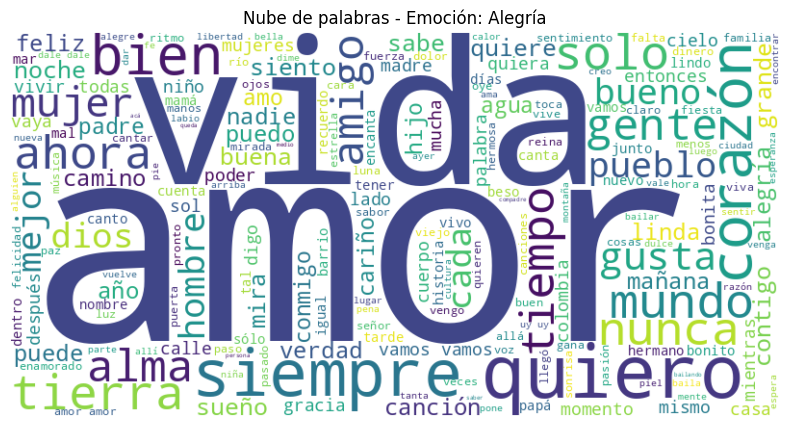

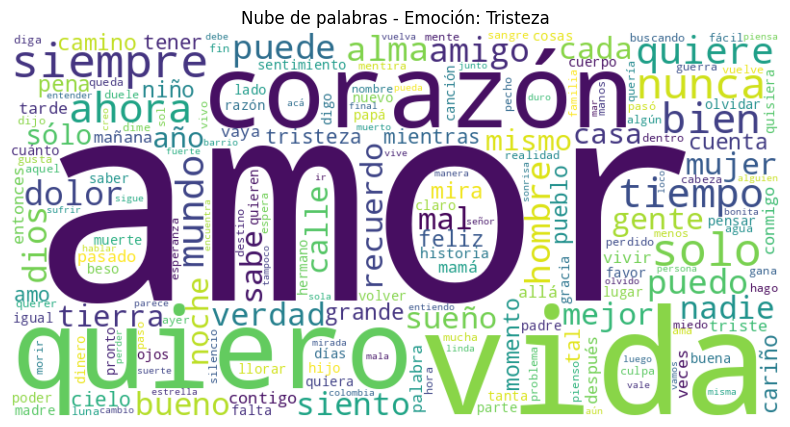

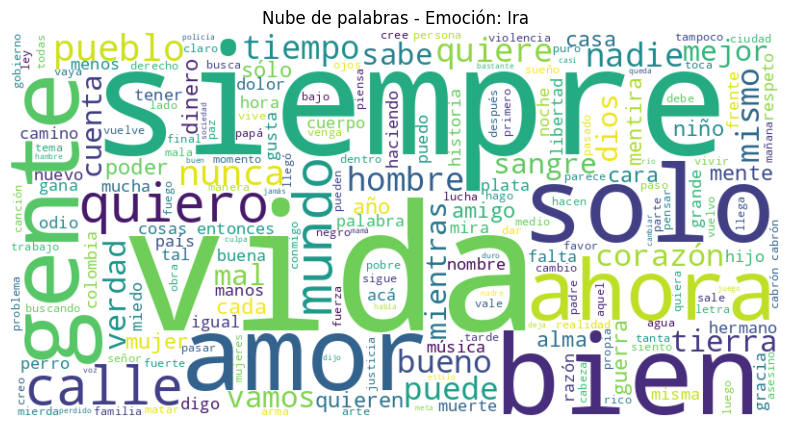

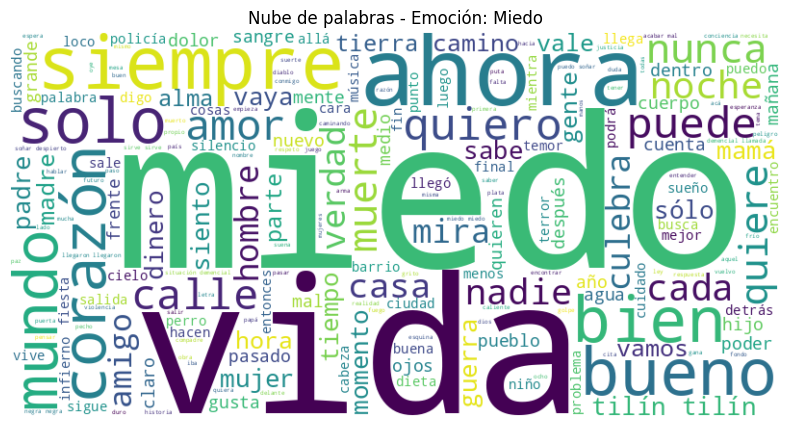

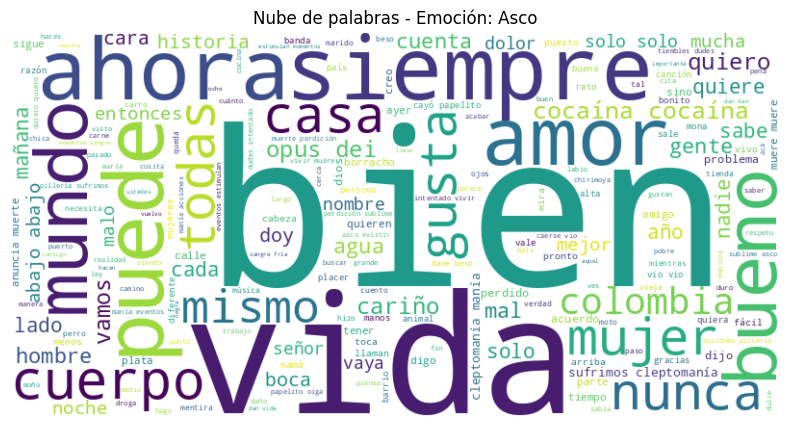

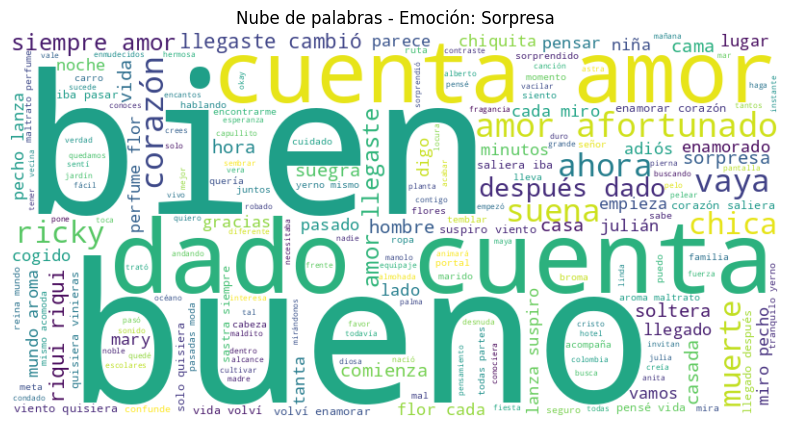

In [ ]:
# Limpiar letras
df["letra_limpia"] = df["LETRA"].apply(limpiar_texto)

# Agrupar por emoción
emociones = df["EMOCION"].unique()

for emocion in emociones:
    texto = " ".join(df[df["EMOCION"] == emocion]["letra_limpia"])

    # Crear nube de palabras
    wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(texto)

    # Mostrar
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Nube de palabras - Emoción: {emocion}")
    plt.show()

In [ ]:
emocion_año = df.groupby(['AÑO', 'EMOCION']).size().unstack(fill_value=0)

In [ ]:
emocion_año.index = emocion_año.index.astype(int)

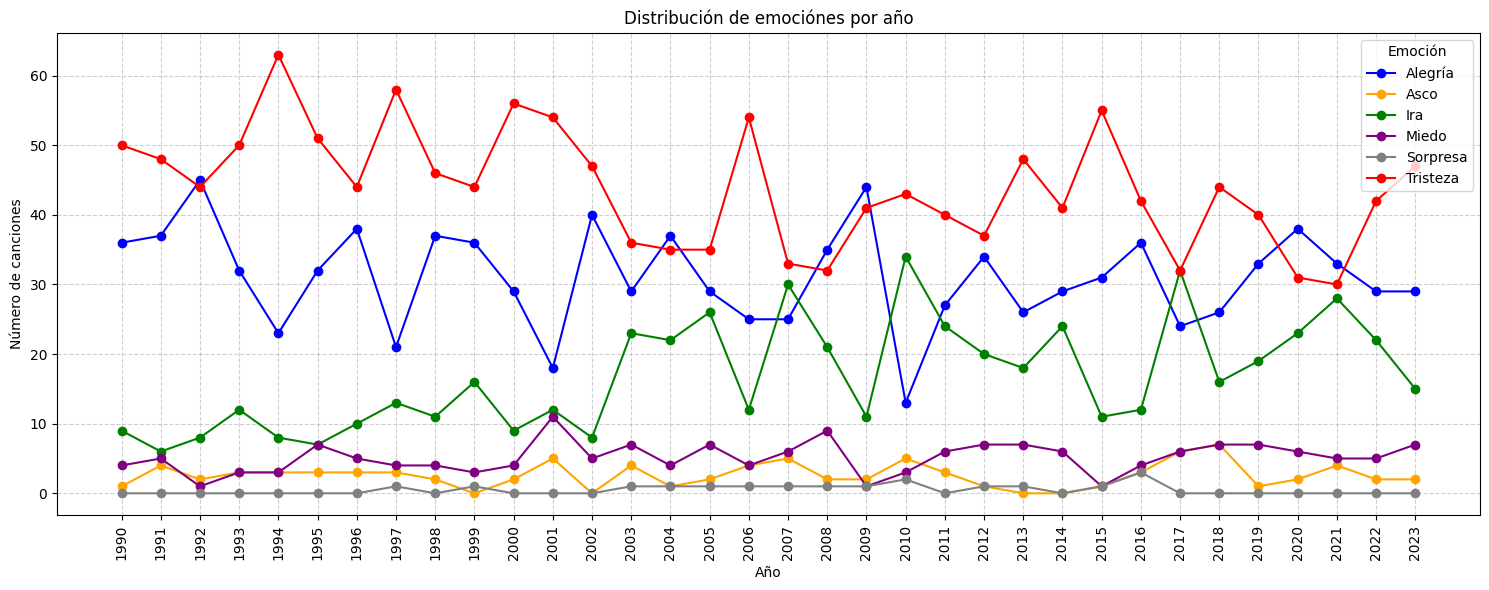

In [ ]:
colores = {
    'Tristeza': 'red',
    'Alegría': 'blue',
    'Ira': 'green',
    'Pendientes': 'yellow',
    'Miedo': 'purple',
    'Asco': 'orange',
    'Sorpresa': 'gray'
}

plt.figure(figsize=(15, 6))

for emocion in emocion_año.columns:
    plt.plot(
        emocion_año.index,
        emocion_año[emocion],
        label=emocion,
        marker='o',
        color=colores.get(emocion, 'gray')
    )

plt.title('Distribución de emociónes por año')
plt.xlabel('Año')
plt.ylabel('Número de canciones')

# Mostrar todos los años de 1990 a 2023
plt.xticks(ticks=range(1990, 2024), rotation=90)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Emoción')
plt.tight_layout()
plt.show()

In [ ]:
# Montar Google Drive
drive.mount('/content/drive')

# Definir ruta
ruta = "/content/drive/MyDrive/Proyecto de profundización 1/PROYECTO GRADO 2025/Resultados modelos/Base ajustada emociones.xlsx"

# Exportar a Excel
df.to_excel(ruta, index=False)

print(f"Archivo guardado en: {ruta}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivo guardado en: /content/drive/MyDrive/Proyecto de profundización 1/PROYECTO GRADO 2025/Resultados modelos/Base ajustada emociones.xlsx
